# Experiment: AlexNet vs Vision Transformer — fixed-time (420s) efficiency on CIFAR-10

Hyperparameters and preprocessing match `validation_alexnet.ipynb` (AlexNet) and `validation_vision_transformers.ipynb` (ViT CIFAR-10 sweep; best config: **num_heads=8**, **dropout=0.0**, **mlp_ratio=4.0**). Run the code cell below (includes optional Colab git sync).

In [ ]:
import os

REPO_NAME = "4803_project_advanced_neural_networks"
REPO_URL = "https://github.com/zarcop/4803_project_advanced_neural_networks"
if not os.path.isdir(REPO_NAME):
    !git clone {REPO_URL}
else:
    !git -C {REPO_NAME} pull

Device: cuda
AlexNet4803 CIFAR-10 (420s)
Vision_Transformers CIFAR-10 (420s)

Comparison @ fixed wall time 420s (CIFAR-10)


,Model,Params,GFLOPs / forward,Samples @ T=420s,Total GFLOPs,Train Acc (%),Val Acc (%),Val gap (Train-Val) (%),Efficiency (ValAcc / Total GFLOPs),Gen. eff. ((2*Val-Train) / Total GFLOPs)
0,AlexNet4803,57763786,2.032864,115360,234511.161508,53.91,55.39,-1.48,0.000236,0.000243
1,Vision_Transformers,809354,0.070078,432256,30291.615220,68.89,67.82,1.07,0.002239,0.002204


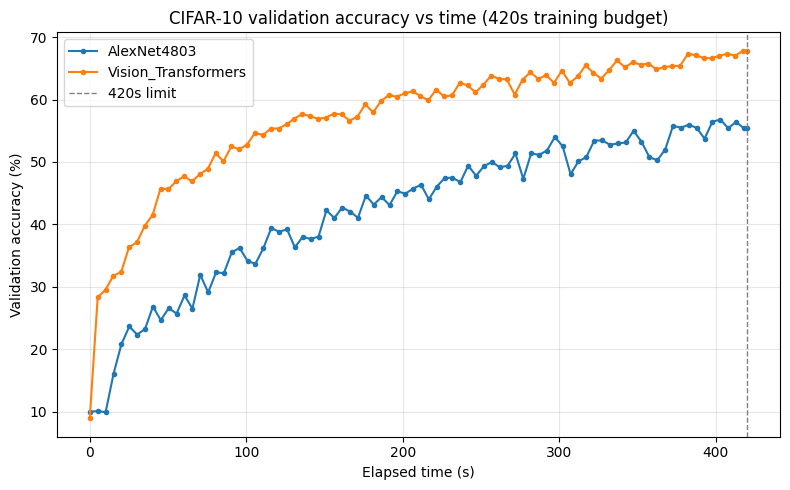

In [2]:


# --- Optional: FLOP estimation (MACs -> GFLOPs via ×2) ---
try:
    from thop import profile as thop_profile
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "thop", "-q"])
    from thop import profile as thop_profile

import importlib.util
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:

    def display(obj):
        print(obj.to_string() if hasattr(obj, "to_string") else obj)

import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

_here = Path.cwd().resolve()
if (_here / "alexnet.py").exists():
    MODEL_DIR = _here
elif (_here / "model" / "alexnet.py").exists():
    MODEL_DIR = _here / "model"
else:
    MODEL_DIR = Path("/content/4803_project_advanced_neural_networks/model")
    if not MODEL_DIR.exists():
        raise FileNotFoundError(f"Cannot find model dir; cwd={_here}")

if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

spec_a = importlib.util.spec_from_file_location("alexnet", MODEL_DIR / "alexnet.py")
mod_a = importlib.util.module_from_spec(spec_a)
spec_a.loader.exec_module(mod_a)
AlexNet4803 = mod_a.AlexNet4803

spec_v = importlib.util.spec_from_file_location("vision_transformers", MODEL_DIR / "vision_transformers.py")
mod_v = importlib.util.module_from_spec(spec_v)
spec_v.loader.exec_module(mod_v)
Vision_Transformers = mod_v.Vision_Transformers

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

TIME_LIMIT = 420.0
BATCH_SIZE = 128
VAL_EVERY_SEC = 5.0

# AlexNet: validation_alexnet.ipynb (CIFAR-10)
ALEX_LR = 1e-3
ALEX_K1, ALEX_S1, ALEX_P1 = 5, 1, 2
alex_cifar_mean = (0.4914, 0.4822, 0.4465)
alex_cifar_std = (0.2470, 0.2435, 0.2616)
alex_train_tf = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(alex_cifar_mean, alex_cifar_std),
    ]
)
alex_val_tf = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(alex_cifar_mean, alex_cifar_std),
    ]
)

# ViT: validation_vision_transformers.ipynb (CIFAR-10; best row: heads=8, drop=0, mlp_ratio=4)
VIT_IMG_SIZE = 32
VIT_PATCH = 4
VIT_EMBED = 128
VIT_DEPTH = 4
VIT_HEADS = 8
VIT_MLP_RATIO = 4.0
VIT_DROPOUT = 0.0
VIT_LR = 3e-4
VIT_WEIGHT_DECAY = 0.05
VIT_LABEL_SMOOTH = 0.1
vit_cifar_mean = (0.4914, 0.4822, 0.4465)
vit_cifar_std = (0.229, 0.224, 0.225)
vit_train_tf = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(vit_cifar_mean, vit_cifar_std),
    ]
)
vit_val_tf = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(vit_cifar_mean, vit_cifar_std),
    ]
)

train_alex = datasets.CIFAR10(root="./data", train=True, download=True, transform=alex_train_tf)
test_alex = datasets.CIFAR10(root="./data", train=False, download=True, transform=alex_val_tf)
train_vit = datasets.CIFAR10(root="./data", train=True, download=True, transform=vit_train_tf)
test_vit = datasets.CIFAR10(root="./data", train=False, download=True, transform=vit_val_tf)

train_loader_alex = DataLoader(train_alex, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_alex = DataLoader(test_alex, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
train_loader_vit = DataLoader(train_vit, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_vit = DataLoader(test_vit, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


def evaluate_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            logits = model(inputs)
            pred = logits.argmax(dim=1)
            total += targets.size(0)
            correct += (pred == targets).sum().item()
    return 100.0 * correct / total


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def gflops_per_forward(model, device, c, h, w):
    model.eval()
    dummy = torch.randn(1, c, h, w, device=device)
    try:
        macs, _ = thop_profile(model, inputs=(dummy,), verbose=False)
    except Exception as exc:
        print(f"thop FLOP estimate failed ({exc}); GFLOP-based metrics will be NaN.")
        return float("nan")
    return float(macs) * 2.0 / 1e9


def train_with_bottleneck_val_curve(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    time_limit=420,
    val_every_sec=5.0,
):
    start_time = time.time()
    total_samples_processed = 0
    model.train()
    val_times = []
    val_accs = []
    last_val_elapsed = -1e9

    def maybe_validate():
        nonlocal last_val_elapsed
        elapsed = time.time() - start_time
        if elapsed >= time_limit:
            return False
        if elapsed - last_val_elapsed < val_every_sec:
            return True
        last_val_elapsed = elapsed
        acc = evaluate_accuracy(model, val_loader, device)
        val_times.append(elapsed)
        val_accs.append(acc)
        model.train()
        return True

    while (time.time() - start_time) < time_limit:
        for inputs, targets in train_loader:
            elapsed = time.time() - start_time
            if elapsed >= time_limit:
                return model, total_samples_processed, val_times, val_accs
            maybe_validate()
            if (time.time() - start_time) >= time_limit:
                return model, total_samples_processed, val_times, val_accs
            optimizer.zero_grad()
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            total_samples_processed += inputs.size(0)
    return model, total_samples_processed, val_times, val_accs


def run_benchmark(name, build_model, train_loader, val_loader, chw, *, optimizer_kind, lr, weight_decay, label_smoothing):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    model = build_model().to(device)
    if optimizer_kind == "adamw":
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    c, h, w = chw
    gf_per = gflops_per_forward(model, device, c, h, w)
    n_params = count_params(model)
    t0 = time.time()
    model, n_samples, val_t, val_a = train_with_bottleneck_val_curve(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        device,
        time_limit=TIME_LIMIT,
        val_every_sec=VAL_EVERY_SEC,
    )
    wall = time.time() - t0
    train_acc = evaluate_accuracy(model, train_loader, device)
    val_acc = evaluate_accuracy(model, val_loader, device)
    val_t, val_a = list(val_t), list(val_a)
    end_t = min(TIME_LIMIT, wall)
    if not val_t or abs(val_t[-1] - end_t) > 0.25:
        val_t.append(end_t)
        val_a.append(val_acc)
    val_gap = train_acc - val_acc
    total_gflops = gf_per * n_samples
    eff = val_acc / total_gflops if total_gflops > 0 else float("nan")
    gen_eff = (val_acc - val_gap) / total_gflops if total_gflops > 0 else float("nan")
    return {
        "model": name,
        "params": n_params,
        "gflops_per_forward": gf_per,
        "samples_processed": n_samples,
        "total_gflops_expended": total_gflops,
        "train_acc_pct": train_acc,
        "val_acc_pct": val_acc,
        "val_gap_pct": val_gap,
        "efficiency_ratio": eff,
        "generalization_efficiency_ratio": gen_eff,
        "wall_clock_s": wall,
        "val_curve_t": val_t,
        "val_curve_acc": val_a,
    }


print("AlexNet4803 CIFAR-10 (420s)")
res_alex = run_benchmark(
    "AlexNet4803",
    lambda: AlexNet4803(3, 10, k1=ALEX_K1, s1=ALEX_S1, p1=ALEX_P1),
    train_loader_alex,
    val_loader_alex,
    (3, 64, 64),
    optimizer_kind="adam",
    lr=ALEX_LR,
    weight_decay=0.0,
    label_smoothing=0.0,
)

print("Vision_Transformers CIFAR-10 (420s)")
res_vit = run_benchmark(
    "Vision_Transformers",
    lambda: Vision_Transformers(
        VIT_IMG_SIZE,
        VIT_PATCH,
        3,
        10,
        VIT_EMBED,
        VIT_DEPTH,
        VIT_HEADS,
        VIT_MLP_RATIO,
        VIT_DROPOUT,
    ),
    train_loader_vit,
    val_loader_vit,
    (3, VIT_IMG_SIZE, VIT_IMG_SIZE),
    optimizer_kind="adamw",
    lr=VIT_LR,
    weight_decay=VIT_WEIGHT_DECAY,
    label_smoothing=VIT_LABEL_SMOOTH,
)

table = pd.DataFrame(
    [
        {
            "Model": res_alex["model"],
            "Params": res_alex["params"],
            "GFLOPs / forward": res_alex["gflops_per_forward"],
            "Samples @ T=420s": res_alex["samples_processed"],
            "Total GFLOPs": res_alex["total_gflops_expended"],
            "Train Acc (%)": res_alex["train_acc_pct"],
            "Val Acc (%)": res_alex["val_acc_pct"],
            "Val gap (Train-Val) (%)": res_alex["val_gap_pct"],
            "Efficiency (ValAcc / Total GFLOPs)": res_alex["efficiency_ratio"],
            "Gen. eff. ((2*Val-Train) / Total GFLOPs)": res_alex["generalization_efficiency_ratio"],
        },
        {
            "Model": res_vit["model"],
            "Params": res_vit["params"],
            "GFLOPs / forward": res_vit["gflops_per_forward"],
            "Samples @ T=420s": res_vit["samples_processed"],
            "Total GFLOPs": res_vit["total_gflops_expended"],
            "Train Acc (%)": res_vit["train_acc_pct"],
            "Val Acc (%)": res_vit["val_acc_pct"],
            "Val gap (Train-Val) (%)": res_vit["val_gap_pct"],
            "Efficiency (ValAcc / Total GFLOPs)": res_vit["efficiency_ratio"],
            "Gen. eff. ((2*Val-Train) / Total GFLOPs)": res_vit["generalization_efficiency_ratio"],
        },
    ]
)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print("\nComparison @ fixed wall time 420s (CIFAR-10)")
display(table)

plt.figure(figsize=(8, 5))
plt.plot(res_alex["val_curve_t"], res_alex["val_curve_acc"], label="AlexNet4803", marker="o", markersize=3)
plt.plot(res_vit["val_curve_t"], res_vit["val_curve_acc"], label="Vision_Transformers", marker="o", markersize=3)
plt.xlabel("Elapsed time (s)")
plt.ylabel("Validation accuracy (%)")
plt.title("CIFAR-10 validation accuracy vs time (420s training budget)")
plt.axvline(TIME_LIMIT, color="gray", linestyle="--", linewidth=1, label="420s limit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
